## Simulazione con mistura

In [1]:
## Importo le librerie e funzioni necessarie
import jax
import jax.numpy as jnp
import qutip as qt
import qutip_jax
import numpy as np
import matplotlib.pyplot as plt
from jax.scipy.special import erf, erfc

  #  from matplotlib.pyplot import plot
   # from numpy import sqrt, linspace, exp, sin, cos, abs, angle, log, max, real
    #from scipy.special import erf, erfc
     #from scipy.integrate import cumulative_trapezoid
      #from math import atan2

print("JAX version:", jax.__version__)
print("QuTiP version:", qt.__version__)

JAX version: 0.6.2
QuTiP version: 5.2.0


In [2]:
## Definisco i parametri

gm  = .03 * 2 * np.pi  # photon-cavity coupling
sigma = .1*gm # inverse of the pulse width (sigma = 2*sqrt(log(2))/tpulse)
chi = .5*gm
args = {'gm':gm,'sigma':sigma, 'chi':chi}

nlev = 2
nqubit = 2

print(f"System parameters:")
print(f"  Cavity levels: {nlev}")
print(f"  Qubit levels: {nqubit}")
print(f"  Coupling photon-cavity: {gm}")
print(f"  Sigma: {sigma}")
print(f"  Chi: {chi}")

System parameters:
  Cavity levels: 2
  Qubit levels: 2
  Coupling photon-cavity: 0.18849555921538758
  Sigma: 0.01884955592153876
  Chi: 0.09424777960769379


In [3]:
## Definisco gli operatori dei singoli sistemi

with qt.CoreOptions(default_dtype="jax"):

    # Identità di qubit e fotoni
    Iq = qt.identity(2)
    In = qt.identity(nlev)
    
    # Operatori di creazione e distruzione in cavità ed input
    An = qt.destroy(nlev)
    Acn = qt.create(nlev)
    
    # Matrici Sigma del qubit
    Sz = qt.sigmaz()
    Sx = qt.sigmax()
    
    # Proiettori di misura del qubit
    P0 = qt.Qobj([[1,0],[0,0]])
    P1 = qt.Qobj([[0,0],[0,1]])

# Funzione di rotazione 
def Ry(theta):
    with qt.CoreOptions(default_dtype="jax"):
        Sy_jax = qt.sigmay()
        Ry_gate = (-1j * Sy_jax * theta / 2).expm()

    return Ry_gate
    

In [4]:
## Definisco gli operatori complessivi del sistema

with qt.CoreOptions(default_dtype="jax"):

    # Creazione e Distruzione in Input
    ain = qt.tensor(An, In, Iq)
    ainc = ain.dag()
    
    # Creazione e Distruzione in Cavità
    a = qt.tensor(In, An, Iq)
    ac = a.dag()
    
    # Matrici sigma
    sz1 = qt.tensor(In, In, Sz)
    sx1 = qt.tensor(In, In, Sx)
    
    # Proiezioni di misura del qubit
    p0 = qt.tensor(In, In, P0)
    p1 = qt.tensor(In, In, P1)

    # Hamiltoniane
    Hc = qt.Qobj(1j/2*jnp.sqrt(gm)*(ainc*a-ain*ac))
    Hq = qt.Qobj(-chi*ac*a*sz1)

In [5]:
## Definisco funzioni

# Rotazione dello stato rho
@jax.jit
def rot(rho, theta, invert=False):
    with qt.CoreOptions(default_dtype="jax"):
        r = qt.tensor(In, In, Ry(theta))
    if not invert:
        return r * rho * r.dag()
    return r.dag() * rho * r

# Proiezione dello stato rho
def proj(rho, state=0):
    if state == 0:
        p = p0
    else:
        p = p1
    return p*rho*p.dag()

# Coefficient function

@jax.jit
def gu(t, **kwargs):  
    sigma = kwargs.get("sigma")
    dx = sigma * (t)
    out = jnp.sqrt(2*sigma/jnp.sqrt(jnp.pi)*jnp.exp(-dx**2)/erfc(dx))
    return jnp.array(out,float)

@jax.jit
def g0(t, args): #Evoluzione indipendente da t
    """Constant function for time-independent evolution"""
    return 1.0

@jax.jit
def bout(t, **kwargs):
    gm = kwargs.get("gm")
    sigma = kwargs.get("sigma")
    return jnp.sqrt(gm)*a + gu(t, sigma=sigma)*ain

gu(5, sigma=sigma)


Array(0.15356369, dtype=float64)

In [6]:
## Definisco evoluzione e la misura

with qt.CoreOptions(default_dtype="jax"):
    Htot = qt.QobjEvo([Hq,[Hc, gu]], args=args)
    #L = qt.QobjEvo([lambda t: bout(t, sigma=sigma, gm=gm)])
    L = [qt.QobjEvo([ain, gu],  args=args) + jnp.sqrt(gm) * a]

solver = qt.MESolver(
    Htot, L, 
    options={"method": "diffrax", "normalize_output": False})
solver_noint = qt.MESolver(
    Hq, [], 
    options={"method": "diffrax", "normalize_output": False})


def measure_2solver(args, solver, solver_noint, rho0, theta1, theta2, tmeas=[-5,5], meas=0):

    if meas==0:
        meas = [0] * len(tmeas)
        
    else:
        if len(tmeas) != len(meas):
            print("ERROR: lenght of the lists tmeas and meas should be the same if meas isn't equal to 0") 
            return "ERROR"
    
    t_ = []
    rho_ = []
    prob = []

    t_noint = []
    rho_noint = []
    prob_noint = []
    rho0_noint = rho0
    
    for kt,t in enumerate(tmeas[:-1]):
        t0 = tmeas[kt]
        t1 = tmeas[kt+1]
        
        rho0 = rot(rho0, theta1)
        rho0_noint = rot(rho0_noint, theta1)
        simulation = solver.run(rho0, [t0,t1], args=args)
        simulation_noint = solver_noint.run(rho0_noint, [t0,t1], args=args)
        
        tp_noint = simulation_noint.times[:]
        rhop_noint = simulation_noint.states[:]
        rho0_noint = rot(rhop_noint[-1], theta2)
        prob0_noint = proj(rho0_noint, state=0).tr()
        
        tp_ = simulation.times[:]
        rhop_ = simulation.states[:]
        rho0 = rot(rhop_[-1], theta2)
        prob0 = proj(rho0, state=0).tr()
        #print(f"{prob0:.4f}")
        rho0 = proj(rho0, state = meas[kt+1]) #+ meas(rho0, 1)
        rho0_noint = proj(rho0_noint, state = meas[kt+1])
        #rho0 = rho0/rho0.tr()
        #t_ = np.concatenate((t_,tp_))
        #rho_ = jnp.concatenate((rho_,jnp.array(rhop_)))
        prob.append(prob0)
        prob_noint.append(prob0_noint)
        
    prob0 = prob[0]
    prob = 1-jnp.prod(jnp.array(prob))
    
    prob0_noint = prob_noint[0]
    prob_noint = 1-jnp.prod(jnp.array(prob_noint))

    #return -(prob - prob_noint)
    return prob - prob_noint


In [7]:
def measure(args, solver, rho0, theta1, theta2, tmeas=[-5,5], meas=0):

    if meas==0:
        meas = [0] * len(tmeas)
        
    else:
        if len(tmeas) != len(meas):
            print("ERROR: lenght of the lists tmeas and meas should be the same if meas isn't equal to 0") 
            return "ERROR"
    
    t_ = []
    rho_ = []
    prob = []
    
    for kt,t in enumerate(tmeas[:-1]):
        t0 = tmeas[kt]
        t1 = tmeas[kt+1]
        
        rho0 = rot(rho0, theta1)
        #tint = np.linspace(t0,t1,200)
        simulation = solver.run(rho0, [t0,t1], args=args)
        
        tp_ = simulation.times[:]
        rhop_ = simulation.states[:]
        rho0 = rot(rhop_[-1], theta2)
        prob0 = proj(rho0, state=0).tr()
        #print(f"{prob0:.4f}")
        rho0 = proj(rho0, state = meas[kt+1]) #+ meas(rho0, 1)
        #rho0 = rho0/rho0.tr()
        #t_ = np.concatenate((t_,tp_))
        #rho_ = jnp.concatenate((rho_,jnp.array(rhop_)))
        prob.append(prob0)
        
    prob0 = prob[0]
    prob = 1-jnp.prod(jnp.array(prob))

    #return -(prob - prob_noint)
    return prob 

In [8]:
# Genero funzione gradiente
grad_sim = jax.grad(measure,argnums=[3, 4])

print("Optimization Ready:")
print(" - simulation function defined")
print(" - JAX gradient function created")

Optimization Ready:
 - simulation function defined
 - JAX gradient function created


In [9]:
#T = np.linspace(-5,5,200)

#grad_sim(args, solver, rho0, np.pi/4, -np.pi/4)
#measure(args, solver, rho0, np.pi/4, -np.pi/4)
#evolution(args, solver, rho0, 5, t0=-5)
#solver.run(rho0, [-5,5], args=args)

In [14]:
with qt.CoreOptions(default_dtype="jax"):
    psi0 = qt.tensor(qt.basis(nlev,1), qt.basis(nlev,0), qt.basis(nqubit,0))
    rho0 = psi0*psi0.dag()

print(measure(args, solver, rho0, np.pi/2, -np.pi/2)-measure(args, solver_noint, rho0, np.pi/2, -np.pi/2))
#print(grad_sim(args, solver, solver_noint, rho0, np.pi/4, -np.pi/4))

0.03135986249111533


In [11]:
#Ottimizzazione
def optimize_time(args, rho0, tmeas, Theta=[np.pi/4, -np.pi/4], learning_rate=0.2, max_iterations=10, tolerance=1e-6):
    """
    Optimize the time using gradient descent.
    
    Args:
        initial_time: Initial guess for optimal time
        learning_rate: Step size for gradient descent
        max_iterations: Maximum number of iterations
        tolerance: Convergence tolerance
    
    Returns:
        optimal_time: The optimized time
        history: History of optimization process
    """
    theta0 = Theta[0]
    theta1 = Theta[1]
    
    history = {'loss': [], 'theta values': [], 'gradient': []}
    
    print(f"Starting optimization with starting theta values: alpha0 {theta0:.3f}, alpha1 {theta1:.3f}")
    print("Iter\tTheta0\t\tTheta1\t\tGradient0\tGradient1\tLoss")
    print("-" * 100)
    
    for i in range(max_iterations):
        # Calculate objective and gradient
        prob = measure(args, solver, rho0, theta0, theta1, tmeas=tmeas, meas=0)
        prob_noint = measure(args, solver_noint, rho0, theta0, theta1, tmeas=tmeas, meas=0)
        loss = prob - prob_noint
        
        grad = grad_sim(args, solver, rho0, theta0, theta1, tmeas=tmeas, meas=0)
        grad_noint = grad_sim(args, solver_noint, rho0, theta0, theta1, tmeas=tmeas, meas=0)
        
        grad0 = -grad[0] + grad_noint[0]
        grad1 = -grad[1] + grad_noint[1]
        
        # Store history
        history['loss'].append(float(loss))
        history['theta values'].append([float(theta0),float(theta1)])  # Convert back to positive
        history['gradient'].append([float(grad0),float(grad1)])

        grad_mod=np.abs(grad0)+np.abs(grad1)
        
        # Print progress
        if i % 100 == 0 or i < 5:
            print(f"{i:3d}\t{theta0:.6f}\t{theta1:.6f}\t{grad0:.6f}\t{grad1:.6f}\t{loss:.6f}")


        
        # Check convergence
        if grad_mod < tolerance:
            print(f"\nConverged after {i+1} iterations!")
            break
        
        # Update time (gradient descent step)
        theta0 = theta0 - learning_rate * grad0
        theta1 = theta1 - learning_rate * grad1
    if i == max_iterations-1:
        print(f"\n Raggiunto epoca massima {i}, senza scendere sotto al valore di tolleranza")
    return theta0, theta1, history

In [26]:
# Run the optimization
Theta = [np.random.normal(0,np.pi),np.random.normal(0,np.pi)]
tmeas=[-5,5]
theta0, theta1, opt_history = optimize_time(args, rho0, tmeas, Theta=Theta, learning_rate=0.5, max_iterations=10000, tolerance=1e-6)

print(f"\nOptimal rotations found: {theta0:.6f}, {theta1:.6f}")
print(f"Minimum loss: {measure(args, solver, rho0, theta0, theta1, tmeas=tmeas, meas=0) - measure(args, solver_noint, rho0, theta0, theta1, tmeas=tmeas, meas=0)}")

Starting optimization with starting theta values: alpha0 -3.120, alpha1 2.398
Iter	Theta0		Theta1		Gradient0	Gradient1	Loss
----------------------------------------------------------------------------------------------------
  0	-3.119688	2.398229	0.021218	-0.000506	0.000465
  1	-3.109079	2.397976	0.021218	-0.000750	0.000690
  2	-3.098470	2.397601	0.021218	-0.000995	0.000916
  3	-3.087861	2.397103	0.021219	-0.001239	0.001141
  4	-3.077252	2.396484	0.021220	-0.001482	0.001367
100	-2.126838	1.971655	0.015240	-0.010393	0.024524
200	-1.693374	1.661361	0.003819	-0.002815	0.030997
300	-1.596116	1.589524	0.000794	-0.000587	0.031344
400	-1.576010	1.574653	0.000164	-0.000121	0.031359
500	-1.571870	1.571590	0.000034	-0.000025	0.031360
600	-1.571017	1.570960	0.000007	-0.000005	0.031360
700	-1.570842	1.570830	0.000001	-0.000001	0.031360

Converged after 759 iterations!

Optimal rotations found: -1.570815, 1.570810
Minimum loss: 0.031359862483083756


In [15]:
# SIMULAZIONE CON MISTURA

psi0 = qt.tensor(qt.basis(nlev,1), qt.basis(nlev,0), qt.basis(2,0))
rho0 = psi0*psi0.dag()

tint = np.array([-5,5])/sigma
# tint = np.array([-5,-1.5,-1,-.5,0,.5,1,1.5,5])/sigma
# tint = np.array([-5,-1.5,-.5,.5,1.5,5])/sigma
# tint = np.array([-5, 5])/sigma

t_ = []
rho_ = []
prob = []
for kt,t in enumerate(tint[:-1]):
    t1 = tint[kt]
    t2 = tint[kt+1]
    rho0 = rot(rho0,0)
    tp_,rhop_ = sim(args,rho0,t1,t2)
    rho0 = rot(rhop_[-1], 1)
    print(f"{1-proj(rho0, 0).tr():.4f}")
    rho0 = proj(rho0, 0) #+ meas(rho0, 1)
    #rho0 = rho0/rho0.tr()
    t_ = np.concatenate((t_,tp_))
    rho_ = np.concatenate((rho_,rhop_))
    prob.append(1-proj(rho0, 0).tr())

b2in_ = [gu(t_[kr],args)**2*expect(ainc*ain, rho) for kr,rho in enumerate(rho_)]
b2out_ = [expect(d(bout(t_[kr],args))*bout(t_[kr],args), rho) for kr,rho in enumerate(rho_)]
nout_ = cumulative_trapezoid(b2out_, t_, initial=0)

fig1,(ax1,ax2) = plt.subplots(2,1, figsize=(6,6))
ax1.plot( t_, [(1-expect(sx1, rho))/2 for rho in rho_], ':', label = r'$P_0^{qubit}$')
ax1.plot( t_, [expect(ainc*ain, rho) for rho in rho_], label = r'$\langle a_{in}^{\dag} a_{in} \rangle$' )
ax1.plot( t_, [expect(ac*a, rho) for rho in rho_], label = r'$\langle a^{\dag} a \rangle$')
ax1.plot( t_, nout_ , label = r'$\langle a_{out}^{\dag} a_{out} \rangle$' )
ax1.fill( t_, b2in_/max(b2in_) , alpha = 0.3, label = 'Input photon' )
for t in tint:
    ax1.plot([t,t],[0,1], 'gray')
ax1.legend(loc="center left")
ax1.set_xlabel('Time')

ax2.plot( t_, b2in_ , label = 'Input photon' )
ax2.plot( t_, b2out_, label = 'Output photon')
for t in tint:
    ax2.plot([t,t],[0,max(b2out_)], 'gray')
ax2.legend(loc="center left")
ax2.set_xlabel('Time')
plt.tight_layout()


NameError: name 'sim' is not defined

## Simulazione con tutti i possibili risultati

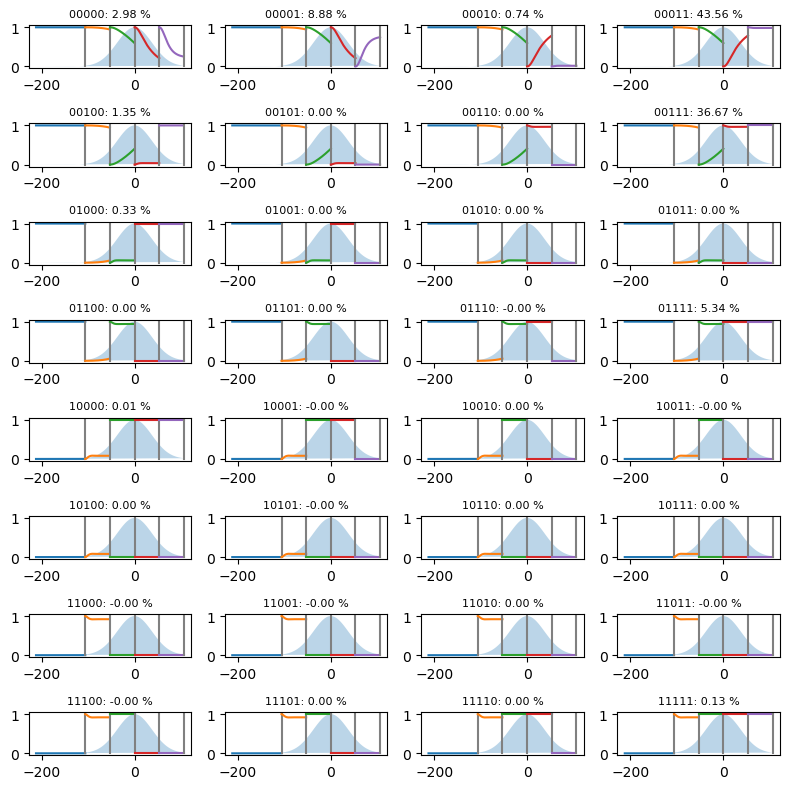

In [22]:
# SIMULAZIONI CON TUTTI I RISULTATI POSSIBILI

import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from numpy import pi, sqrt, linspace, exp, sin, cos, abs, angle, log, max, real
from scipy.special import erf, erfc
from scipy.integrate import cumulative_trapezoid
from math import atan2

k  = 3.0e-2 * 2 * pi  # photon-cavity coupling
sigma = .1*k # inverse of the pulse width (sigma = 2*sqrt(log(2))/tpulse)
chi = .5*k
args = {'gm':k,'sigma':sigma, 'chi':chi}

nlev = 2
nqubit = 2

I2 = identity(2)
In = identity(nlev)
An = destroy(nlev)
Acn = create(nlev)
Sz = sigmaz()
Sx = sigmax()
Rx = Qobj([[1,-1],[1,1]])/sqrt(2)
Ry = Qobj([[1,-1j],[-1j,1]])/sqrt(2)
P0 = Qobj([[1,0],[0,0]])
P1 = Qobj([[0,0],[0,1]])

def d(O):
    return O.dag()

ain = qt.tensor(An, In, I2)
ainc = d(ain)
a = qt.tensor(In, An, I2)
ac = d(a)
sz1 = qt.tensor(In, In, Sz)
sx1 = qt.tensor(In, In, Sx)

r = qt.tensor(In, In, Rx)
p = [qt.tensor(In, In, P0), qt.tensor(In, In, P1)]

def rot0(rho, verso = 0):
    if verso ==0:
        return r*rho*r.dag()
    else:
        return r.dag()*rho*r

def rot(rho, verso = 0): # ROTAZIONE
    if isinstance(rho,(list,np.ndarray)):
        return [ rot0(rhoin,verso) for rhoin in rho]
    else:
        return rot0(rho,verso)

def proj(rho, state): # PROIEZIONE
    if isinstance(rho,(list,np.ndarray)):
        return [ p[state]*rhoin*p[state].dag() for rhoin in rho]
    else:
        return p[state]*rho*p[state].dag()

def meas(rho, state): # MISURA
    if isinstance(rho,(list,np.ndarray)):
        return [ (p[state]*rhoin*p[state].dag()).tr() for rhoin in rho]
    else:
        return (p[state]*rho*p[state].dag()).tr()

def u0(t, args):
    sigma = args['sigma']
    dx = sigma * t
    if isinstance(dx,(list,np.ndarray)):
        return [float(exp(-dx0**2)) for dx0 in dx]
    else:
        return float(exp(-dx**2))

def gu(t, args):  # coefficient function
    sigma = args['sigma']
    dx = sigma * (t)
    out = sqrt(2*sigma/sqrt(pi)*exp(-dx**2)/erfc(dx))
    return float(out)

def bout(t, args):
    gm = args['gm']
    return sqrt(gm)*a + gu(t, args)*ain

def sim(args,rho0,t1,t2):
    gm = args['gm']
    chi = args['chi']
    Hc = 1j/2*sqrt(gm)*(ainc*a-ain*ac)
    Hq = -chi*ac*a*sz1
    H = [Hq,[Hc, gu]]
    L = [lambda t, args: bout(t, args)]

    t_ = linspace(t1, t2, 200)
    rho_ = mesolve(H, rho0, t_, L, args=args).states # SIMULAZIONE
    return t_,rho_

psi0 = qt.tensor(basis(nlev,1), basis(nlev,0), basis(2,0))

tint = np.array([-4,-2,-1,0,1,2])/sigma # Possibili sequenze di misure
#tint = np.array([-5,-1.5,-1,-.5,0,.5,1,1.5,5])/sigma
# tint = np.array([-5,-1.5,-.5,.5,1.5,5])/sigma
# tint = np.array([-5,-1,0,1,5])/sigma
# tint = np.array([-5,-.5,.5, 5])/sigma
# tint = np.array([-5, 0, 5])/sigma
# tint = np.array([-5, 5])/sigma

nmeas = len(tint)-1
tot = 0
Kseq = np.arange(0,2**nmeas,1) # Sequenze di risultati possibili
Pseq = []

fig,ax = plt.subplots(int(2**nmeas/4),4,figsize=(8,int(2**nmeas/4)))
# Scorro le diverse sequenze di possibili risultati. Ogni seguenza è un numero binario, 0 sta per risultato |0>, 1 per risultato |1>
for kseq in Kseq:
    t_ = []
    rho_ = []
    prob = []
    rho0 = psi0*psi0.dag()
    str = format(kseq, f'0{nmeas}b') # Stringa di bit che descrivono sequenza di risultati kseq
    xpos = [int(bit) for bit in str] # Array di bit che descrivono sequenza di risultati kseq
    for kt,t in enumerate(tint[:-1]): # Scorro i diversi tratti
        t1 = tint[kt]
        t2 = tint[kt+1]
        rho0 = rot(rho0,0) # Rotazione di pi/2 dello stato iniziale
        tp_,rhop_ = sim(args,rho0,t1,t2) # Evoluzione
        rho0 = rot(rhop_[-1], 1)  # Rotazione di -pi/2 dell'ultimo stato
        rho0 = proj(rho0, xpos[kt]) # Proiezione dello stato sul risultato xpos[kt]
        #if kt==0:
        #    ax[kseq//4,kseq%4].plot(tp_,meas(rot(rhop_,1),0)) # Plot probabilità in tutto il tratto
        #else:
        #    ax[kseq//4,kseq%4].plot(tp_,meas(rot(rhop_,1),xpos[kt-1])) # Plot probabilità in tutto il tratto
        meas1 = np.around(np.array(meas(rot(rhop_,1),1)),6)
        meas0 = np.around(np.array(meas(rot(rhop_,1),0)),6)
        norm = meas1 + meas0
        if xpos[kt]== 0:
            p_norm = meas0
        else:
            p_norm = meas1
        maskp_norm = np.not_equal(norm,0)
        p_norm[maskp_norm] = p_norm[maskp_norm]/norm[maskp_norm]
        
        ax[kseq//4,kseq%4].plot(tp_, p_norm) # Plot probabilità in tutto il tratto (normalizzata)§
        
        ax[kseq//4,kseq%4].plot([t2,t2],[0,1], 'gray') # Plot del confine del tratto
        t_ = np.concatenate((t_,tp_))
        rho_ = np.concatenate((rho_,rhop_))
        prob.append(1-proj(rho0, 0).tr())
    ax[kseq//4,kseq%4].fill(t_,u0(t_,args), alpha=.3) # Plot dell'input pulse
    ax[kseq//4,kseq%4].set_title(f"{str}: {100*meas(rho0, xpos[-1]):.2f} %", fontsize=8)
    Pseq.append(meas(rho0, xpos[-1])) # Probabilità finale
plt.tight_layout()

In [4]:
# VALUTAZIONE DELLE PROBABILITÀ
sumP = np.zeros(nmeas+1)
for kseq in Kseq:
    str = format(kseq, f'0{nmeas}b')
    xpos = [int(bit) for bit in str]
    sumP[np.sum(xpos)] += Pseq[kseq]

p = 1- np.cumsum(sumP)
print(f"Nessuno:  p = {100*Pseq[0]:.2f}%")
for kp,p0 in enumerate(p[:-1]):
    print(f"Almeno {kp+1}: p = {100*p0:.2f}%")

Nessuno:  p = 2.98%
Almeno 1: p = 97.02%
Almeno 2: p = 85.71%
Almeno 3: p = 42.14%
Almeno 4: p = 5.47%
Almeno 5: p = 0.13%
